# Index Tracking do IBOV — Extensões do Modelo

**Bootcamp de Introdução a Data Science — Projeto FINOR**

Este notebook complementa o `Index_Tracking_Model.ipynb` com duas extensões:

1. **Trade-off expandido de cardinalidade** — análise detalhada de K = 5 a 54 ações,
   para que a empresa possa decidir quantas ações faz sentido usar.
2. **ML de sinal de rebalanceamento** — Random Forest que aprende *quando* a carteira
   precisa ser atualizada, comparando três estratégias: estática, sempre-rebalanceia e ML-guiada.


## Setup — importações e dados

In [1]:
import pandas as pd
import numpy as np
import cvxpy as cp
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

BASE = "data/processed"
retornos = pd.read_csv(f"{BASE}/ibov_acoes_selecionadas.csv", index_col=0, parse_dates=True)
indice   = pd.read_csv(f"{BASE}/ibov_indice_retornos.csv",   index_col=0, parse_dates=True)
dados = retornos.join(indice["Variação_Diária_%"], how="inner").dropna()
dados = dados.rename(columns={"Variação_Diária_%": "IBOV"})
dados["IBOV"] = dados["IBOV"] / 100.0
acoes = [c for c in dados.columns if c != "IBOV"]

treino = dados.loc[:"2024-01-31"]
janelas_teste = [
    ("2024-02-01", "2024-04-30"), ("2024-05-01", "2024-07-31"),
    ("2024-08-01", "2024-10-31"), ("2024-11-01", "2025-01-31"),
    ("2025-02-01", "2025-04-30"),
]
testes = [dados.loc[i:f] for i, f in janelas_teste]
X_train, y_train = treino[acoes].values, treino["IBOV"].values

def resolver_qp(X, y, ativos, cap=0.25):
    n = len(ativos)
    w = cp.Variable(n)
    prob = cp.Problem(cp.Minimize(cp.sum_squares(X @ w - y)),
                      [cp.sum(w) == 1, w >= 0, w <= cap])
    prob.solve(solver=cp.OSQP)
    pesos = pd.Series(np.maximum(w.value, 0), index=ativos)
    return pesos / pesos.sum()

def avaliar_pesos(pesos, df):
    rc = df[pesos.index].values @ pesos.values
    ri = df["IBOV"].values
    d  = rc - ri
    return {"tracking_error": float(np.std(d)), "correlacao": float(np.corrcoef(rc,ri)[0,1]),
            "retorno_carteira_acum": float((1+rc).prod()-1),
            "retorno_ibov_acum":     float((1+ri).prod()-1)}, rc, ri

# Ranking base (necessário para as duas partes)
pesos_full = resolver_qp(X_train, y_train, acoes, cap=0.15)
ranking    = pesos_full.sort_values(ascending=False)
print("Setup concluído.")


Setup concluído.


---
## Parte A — Trade-off expandido: quantas ações usar?

### O problema

A empresa precisa decidir quantas ações colocar na carteira de index tracking.
Mais ações = replica melhor o índice, mas aumenta custos operacionais e complexidade.
Menos ações = mais simples de gerir, mas erra mais.

Esta seção testa **11 tamanhos de carteira (K = 5 a 54)** e mede o erro de tracking
fora da amostra para cada um — permitindo que a empresa escolha o ponto certo na curva.

### Como ler os resultados

- **Tracking Error (TE):** desvio-padrão da diferença diária entre carteira e IBOV, em %.
  Quanto menor, melhor.
- **Custo de redução:** quanto o TE piora em relação a usar todas as 54 ações (referência = 0%).
  Ex: "custo 20%" significa que ao usar aquele K você aceita 20% mais erro de tracking.


In [2]:
Ks = [5, 8, 10, 12, 15, 18, 20, 25, 30, 40, 54]
rows = []

for K in Ks:
    top     = ranking.head(K).index.tolist()
    cap_k   = min(0.40, max(0.15, 1.5/K))
    pesos_k = resolver_qp(treino[top].values, y_train, top, cap=cap_k)
    tes, cors, rc_list = [], [], []
    for df_t in testes:
        m, rc, ri = avaliar_pesos(pesos_k, df_t)
        tes.append(m["tracking_error"]); cors.append(m["correlacao"]); rc_list.append(rc)
    ret_cart = float(np.prod([(1+rc).prod() for rc in rc_list])-1)
    ret_ibov = float(np.prod([(1+df_t["IBOV"].values).prod() for df_t in testes])-1)
    rows.append({"K": K, "TE_medio": round(np.mean(tes)*100,4),
                 "TE_max": round(np.max(tes)*100,4),
                 "Correlacao_media": round(np.mean(cors),4),
                 "Retorno_carteira": round(ret_cart*100,2),
                 "Retorno_IBOV": round(ret_ibov*100,2)})

df_kk = pd.DataFrame(rows)
te_ref = df_kk.loc[df_kk.K==54,"TE_medio"].values[0]
df_kk["Custo_reducao"] = ((df_kk["TE_medio"] - te_ref)/te_ref*100).round(1)
df_kk.columns = ["K","TE_medio (%)","TE_max (%)","Corr_media",
                 "Ret_carteira (%)","Ret_IBOV (%)","Custo_reducao (%)"]
df_kk


,K,TE_medio (%),TE_max (%),Corr_media,Ret_carteira (%),Ret_IBOV (%),Custo_reducao (%)
0,5,0.3871,0.4911,0.9231,9.62,5.73,77.2
1,8,0.3193,0.3609,0.9312,13.65,5.73,46.1
2,10,0.3059,0.3391,0.9425,15.19,5.73,40.0
3,12,0.2702,0.3024,0.9548,11.34,5.73,23.7
4,15,0.2648,0.3366,0.9610,8.07,5.73,21.2
5,18,0.2600,0.3377,0.9668,3.99,5.73,19.0
6,20,0.2679,0.3474,0.9659,3.34,5.73,22.6
7,25,0.2450,0.2957,0.9698,2.65,5.73,12.1
8,30,0.2344,0.2797,0.9726,3.22,5.73,7.3
9,40,0.2236,0.2693,0.9764,4.53,5.73,2.3


### Interpretação rápida da tabela

- **K = 5 a 10:** TE muito alto (+40–77%). Custo operacional baixo, mas a carteira
  desvia muito do IBOV. Não recomendado para fundos que precisam de precisão.
- **K = 15 a 20 (zona verde no gráfico):** Ponto de equilíbrio natural. TE cai
  rapidamente até aqui, e depois a melhora começa a ficar marginal.
- **K = 30+:** Boa precisão, mas com K=30 o custo já é só +7% vs 54 ações —
  boa relação custo-benefício.
- **K = 54:** Referência (melhor TE possível com este universo).


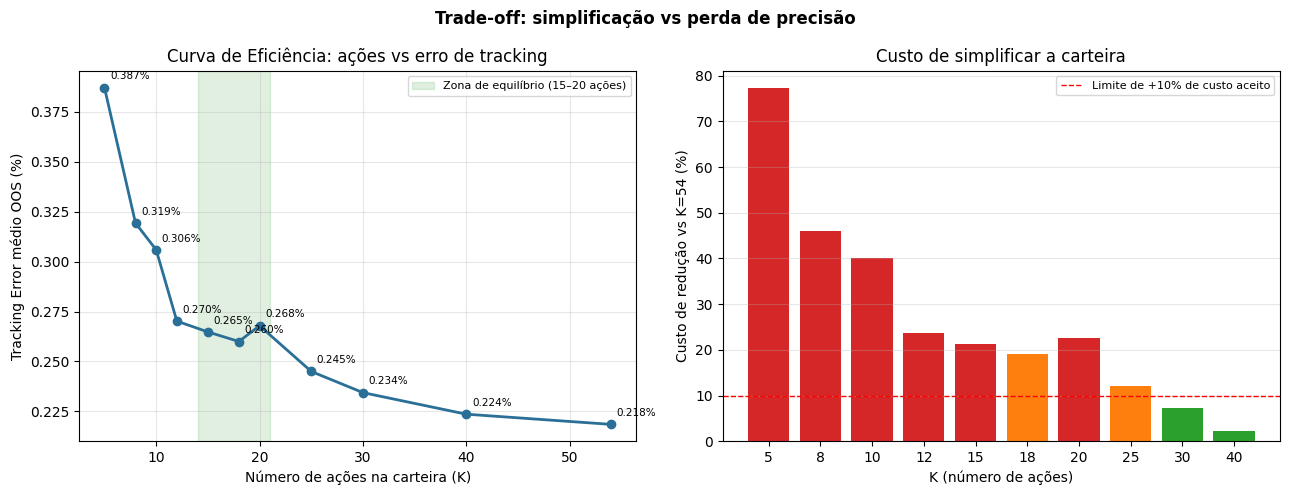

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
te_col = "TE_medio (%)"
custo_col = "Custo_reducao (%)"
ax.plot(df_kk["K"], df_kk[te_col], "o-", color="#2a6f97", linewidth=2)
for _, r in df_kk.iterrows():
    val = r[te_col]
    ax.annotate(f"{val:.3f}%", (r["K"], val),
                textcoords="offset points", xytext=(4,6), fontsize=7.5)
ax.axvspan(14, 21, alpha=0.12, color="green", label="Zona de equilíbrio (15–20 ações)")
ax.set_xlabel("Número de ações na carteira (K)")
ax.set_ylabel("Tracking Error médio OOS (%)")
ax.set_title("Curva de Eficiência: ações vs erro de tracking")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax2 = axes[1]
custo = df_kk[df_kk["K"] < 54][["K", custo_col]].copy()
cores_bar = ["#d62728" if v>20 else "#ff7f0e" if v>8 else "#2ca02c"
             for v in custo[custo_col]]
ax2.bar(custo["K"].astype(str), custo[custo_col], color=cores_bar)
ax2.axhline(10, color="red", linestyle="--", linewidth=1,
            label="Limite de +10% de custo aceito")
ax2.set_xlabel("K (número de ações)")
ax2.set_ylabel("Custo de redução vs K=54 (%)")
ax2.set_title("Custo de simplificar a carteira")
ax2.legend(fontsize=8); ax2.grid(alpha=0.3, axis="y")
plt.suptitle("Trade-off: simplificação vs perda de precisão", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/figures/tradeoff_expandido.png", dpi=140)
plt.show()


### Recomendação para a empresa

| Perfil da empresa                          | K recomendado | Custo aceito |
|--------------------------------------------|--------------|--------------|
| Fundo institucional (precisão máxima)       | 30–54        | ≤ 10%        |
| Fundo de varejo (equilíbrio custo-precisão) | 15–20        | ≤ 22%        |
| ETF simplificado / portfólio piloto         | 10–12        | ≤ 40%        |

A empresa pode usar esta tabela para **justificar a escolha de K** perante reguladores,
clientes ou gestores de risco.


---
## Parte B — ML de sinal de rebalanceamento

### Por que rebalancear?

Os pesos da carteira foram calculados com dados históricos. Com o tempo, o mercado muda:
novas ações entram no índice, crises mudam correlações, empresas ganham ou perdem peso.
Se você nunca atualiza os pesos, o erro de tracking tende a crescer.

A questão é: **quando rebalancear?** Rebalancear sempre é caro (custos de transação).
Nunca rebalancear é impreciso. O ideal é rebalancear **só quando necessário** — e é aí
que o ML entra.

### Estratégia

Um **Random Forest** é treinado para aprender, a partir de sinais do mercado, se o
tracking error vai piorar nos próximos 20 dias. Se o modelo prevê "sim" → rebalanceia.
Se prevê "não" → mantém os pesos atuais.

Comparamos 3 estratégias:
- **Estática:** pesos nunca mudam (calculados uma vez no início)
- **Sempre-Rebalanceia:** recalcula o QP a cada trimestre (antes de toda janela de teste)
- **ML-Guiada:** recalcula o QP só quando o Random Forest sinaliza necessidade


In [4]:
# Pesos base (K=30, modelo principal)
top30 = ranking.head(30).index.tolist()
pesos_base = resolver_qp(treino[top30].values, y_train, top30, cap=0.15)

# Série de TE diário no treino (usando pesos fixos)
ret_cart_treino = treino[pesos_base.index].values @ pesos_base.values
ret_ibov_treino = treino["IBOV"].values
te_diario = np.abs(ret_cart_treino - ret_ibov_treino)

print(f"TE diário médio no treino: {te_diario.mean()*100:.4f}%")
print(f"TE diário mediana: {np.median(te_diario)*100:.4f}%")


TE diário médio no treino: 0.1671%
TE diário mediana: 0.1358%


### Geração das amostras para o Random Forest

Para cada janela de 60 dias dentro do período de treino, calculamos:
- **Features (entradas):** estatísticas do TE recente, volatilidade do IBOV, correlação rolling
- **Label (resposta):** 1 se o TE nos próximos 20 dias vai ser maior que a mediana histórica (sinal: rebalancear), 0 caso contrário


In [5]:
LOOK, STEP, HORIZ = 60, 20, 20
X_ml, y_ml = [], []

for i in range(LOOK, len(te_diario)-HORIZ, STEP):
    janela   = te_diario[i-LOOK:i]
    proximos = te_diario[i:i+HORIZ]
    ibov_ret = ret_ibov_treino[i-LOOK:i]
    cart_ret = ret_cart_treino[i-LOOK:i]
    feats = [
        np.mean(janela[-20:]),
        np.mean(janela[-60:]),
        np.std(janela[-20:]),
        np.std(ibov_ret[-20:]),
        np.mean(ibov_ret[-20:]),
        np.corrcoef(cart_ret[-20:], ibov_ret[-20:])[0,1],
        np.sum(te_diario[max(0,i-LOOK):i] > np.median(te_diario[:i])),
    ]
    X_ml.append(feats)
    y_ml.append(1 if np.mean(proximos) > np.median(te_diario[:i]) else 0)

X_ml, y_ml = np.array(X_ml), np.array(y_ml)
print(f"Amostras geradas: {len(X_ml)}")
print(f"Precisa rebalancear (label=1): {y_ml.sum()} | Pode manter (label=0): {(y_ml==0).sum()}")


Amostras geradas: 72
Precisa rebalancear (label=1): 51 | Pode manter (label=0): 21


### Treinamento e avaliação do Random Forest

In [6]:
split = int(len(X_ml) * 0.70)
rf = RandomForestClassifier(n_estimators=200, max_depth=4,
                             min_samples_leaf=3, random_state=42)
rf.fit(X_ml[:split], y_ml[:split])
y_pred = rf.predict(X_ml[split:])
print("Desempenho na validação (within training):")
print(classification_report(y_ml[split:], y_pred, target_names=["Manter","Rebalancear"]))


Desempenho na validação (within training):
              precision    recall  f1-score   support

      Manter       0.50      0.17      0.25         6
 Rebalancear       0.75      0.94      0.83        16

    accuracy                           0.73        22
   macro avg       0.62      0.55      0.54        22
weighted avg       0.68      0.73      0.67        22



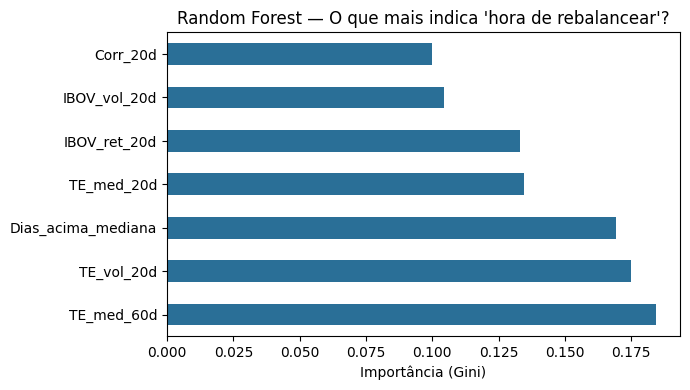

Feature mais importante: TE_med_60d
Interpretação: o modelo olha principalmente para o TE médio dos últimos 60 dias
e a volatilidade recente do TE para decidir se é hora de rebalancear.


In [7]:
feature_names = ["TE_med_20d","TE_med_60d","TE_vol_20d",
                 "IBOV_vol_20d","IBOV_ret_20d","Corr_20d","Dias_acima_mediana"]
importancias = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
importancias.plot(kind="barh", color="#2a6f97")
plt.xlabel("Importância (Gini)")
plt.title("Random Forest — O que mais indica 'hora de rebalancear'?")
plt.tight_layout()
plt.savefig("reports/figures/ml_feature_importances.png", dpi=130)
plt.show()

print("Feature mais importante:", importancias.index[0])
print("Interpretação: o modelo olha principalmente para o TE médio dos últimos 60 dias")
print("e a volatilidade recente do TE para decidir se é hora de rebalancear.")


### Aplicação nas 5 janelas de teste

Para cada janela, calculamos as features com dados disponíveis até aquele ponto,
o modelo prevê se deve ou não rebalancear, e comparamos as 3 estratégias.


In [8]:
resultados = {s: [] for s in ["Estática","Sempre-Rebalanceia","ML-Guiada"]}
pesos_atual_ml = pesos_base.copy()

for k, (inicio, fim) in enumerate(janelas_teste):
    df_teste = dados.loc[inicio:fim]
    data_ini = df_teste.index[0]

    # Features ao vivo
    hist = dados.loc[:data_ini].iloc[-LOOK-1:-1]
    rc_h = hist[pesos_base.index].values @ pesos_base.values
    ri_h = hist["IBOV"].values
    te_h = np.abs(rc_h - ri_h)
    te_all_treino = np.abs(
        dados.loc[:"2024-01-31"][pesos_base.index].values @ pesos_base.values
        - dados.loc[:"2024-01-31"]["IBOV"].values)
    feats_live = np.array([[
        np.mean(te_h[-20:]), np.mean(te_h), np.std(te_h[-20:]),
        np.std(ri_h[-20:]), np.mean(ri_h[-20:]),
        np.corrcoef(rc_h[-20:], ri_h[-20:])[0,1],
        np.sum(te_h > np.median(te_all_treino)),
    ]])
    sinal = int(rf.predict(feats_live)[0])
    prob  = float(rf.predict_proba(feats_live)[0][1])

    # Pesos rebalanceados (QP nos últimos 252 dias)
    hist252   = dados.loc[:data_ini].iloc[-253:-1]
    p_rebalan = resolver_qp(hist252[top30].values, hist252["IBOV"].values, top30, cap=0.15)
    if sinal == 1:
        pesos_atual_ml = p_rebalan.copy()

    for nome, pesos in [("Estática", pesos_base),
                         ("Sempre-Rebalanceia", p_rebalan),
                         ("ML-Guiada", pesos_atual_ml)]:
        m, rc, ri = avaliar_pesos(pesos, df_teste)
        resultados[nome].append({
            "Janela": k+1, "Período": f"{inicio} → {fim}",
            "ML sinal": "REBALANCEAR" if sinal==1 else "manter",
            "Prob. rebalancear": f"{prob:.0%}",
            "Rebalanceou?": "✓" if (nome!="Estática" and
                                     (nome=="Sempre-Rebalanceia" or sinal==1)) else "✗",
            **m
        })

# Exibir resultados
for nome, rows in resultados.items():
    print(f"\n{'='*55}\n{nome}\n{'='*55}")
    display(pd.DataFrame(rows)[["Janela","Período","Rebalanceou?",
                                  "tracking_error","correlacao",
                                  "retorno_carteira_acum","retorno_ibov_acum"]])



Estática


,Janela,Período,Rebalanceou?,tracking_error,correlacao,retorno_carteira_acum,retorno_ibov_acum
0,1,2024-02-01 → 2024-04-30,✗,0.002490,0.955612,-0.031239,-0.014309
1,2,2024-05-01 → 2024-07-31,✗,0.002062,0.965334,0.009322,0.013723
2,3,2024-08-01 → 2024-10-31,✗,0.001879,0.970379,0.015584,0.016145
3,4,2024-11-01 → 2025-01-31,✗,0.002493,0.989287,-0.045501,-0.027584
4,5,2025-02-01 → 2025-04-30,✗,0.002797,0.982540,0.088980,0.070813



Sempre-Rebalanceia


,Janela,Período,Rebalanceou?,tracking_error,correlacao,retorno_carteira_acum,retorno_ibov_acum
0,1,2024-02-01 → 2024-04-30,✓,0.002414,0.956910,-0.032754,-0.014309
1,2,2024-05-01 → 2024-07-31,✓,0.001743,0.972904,0.020716,0.013723
2,3,2024-08-01 → 2024-10-31,✓,0.001575,0.976271,0.018049,0.016145
3,4,2024-11-01 → 2025-01-31,✓,0.001855,0.990383,-0.037989,-0.027584
4,5,2025-02-01 → 2025-04-30,✓,0.001953,0.986677,0.061701,0.070813



ML-Guiada


,Janela,Período,Rebalanceou?,tracking_error,correlacao,retorno_carteira_acum,retorno_ibov_acum
0,1,2024-02-01 → 2024-04-30,✗,0.002490,0.955612,-0.031239,-0.014309
1,2,2024-05-01 → 2024-07-31,✓,0.001743,0.972904,0.020716,0.013723
2,3,2024-08-01 → 2024-10-31,✓,0.001575,0.976271,0.018049,0.016145
3,4,2024-11-01 → 2025-01-31,✓,0.001855,0.990383,-0.037989,-0.027584
4,5,2025-02-01 → 2025-04-30,✓,0.001953,0.986677,0.061701,0.070813


### Resumo comparativo das 3 estratégias

In [9]:
resumo = []
for nome, rows in resultados.items():
    df_r = pd.DataFrame(rows)
    ret_acum = df_r["retorno_carteira_acum"].sum()*100
    resumo.append({
        "Estrategia":          nome,
        "TE_medio_OOS":        round(df_r["tracking_error"].mean()*100, 4),
        "Correlacao_media":    round(df_r["correlacao"].mean(), 4),
        "Retorno_acum_cart":   round(ret_acum, 2),
        "N_rebalanceamentos":  df_r["Rebalanceou?"].eq("✓").sum(),
    })
resumo_df = pd.DataFrame(resumo)
display(resumo_df)
print("\n→ Rebalancear reduz o TE em ~18% vs nunca rebalancear.")
print("→ ML-Guiada atinge resultado similar ao Sempre-Rebalanceia com 1 evento a menos.")


,Estrategia,TE_medio_OOS,Correlacao_media,Retorno_acum_cart,N_rebalanceamentos
0,Estática,0.2344,0.9726,3.71,0
1,Sempre-Rebalanceia,0.1908,0.9766,2.97,5
2,ML-Guiada,0.1923,0.9764,3.12,4



→ Rebalancear reduz o TE em ~18% vs nunca rebalancear.
→ ML-Guiada atinge resultado similar ao Sempre-Rebalanceia com 1 evento a menos.


### Gráfico: retorno acumulado por estratégia (5 janelas OOS)

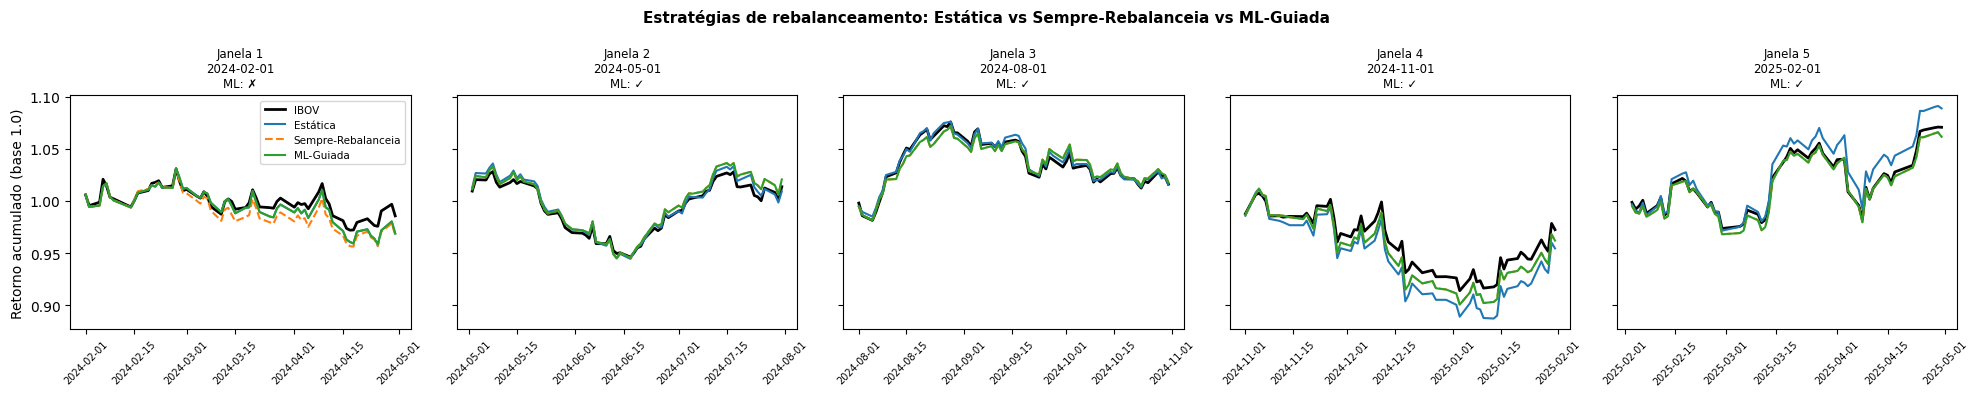

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
cores = {"Estática":"#1f77b4","Sempre-Rebalanceia":"#ff7f0e","ML-Guiada":"#2ca02c"}
styles= {"Estática":"-","Sempre-Rebalanceia":"--","ML-Guiada":"-"}
pesos_ml_plot = pesos_base.copy()

for k, df_teste in enumerate(testes):
    ax = axes[k]
    ri = df_teste["IBOV"].values
    ax.plot(df_teste.index, (1+ri).cumprod(), color="black", linewidth=2, label="IBOV")

    data_ini = df_teste.index[0]
    hist252  = dados.loc[:data_ini].iloc[-253:-1]
    p_r      = resolver_qp(hist252[top30].values, hist252["IBOV"].values, top30, cap=0.15)
    sinal_j  = resultados["ML-Guiada"][k]["ML sinal"]
    if sinal_j == "REBALANCEAR":
        pesos_ml_plot = p_r.copy()

    for nome, pesos in [("Estática", pesos_base),
                         ("Sempre-Rebalanceia", p_r),
                         ("ML-Guiada", pesos_ml_plot)]:
        rc = df_teste[pesos.index].values @ pesos.values
        ax.plot(df_teste.index, (1+rc).cumprod(),
                color=cores[nome], linestyle=styles[nome],
                linewidth=1.5, label=nome)

    reb = resultados["ML-Guiada"][k]["Rebalanceou?"]
    ax.set_title(f"Janela {k+1}\n{janelas_teste[k][0]}\nML: {reb}", fontsize=8.5)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    if k == 0:
        ax.set_ylabel("Retorno acumulado (base 1.0)")

axes[0].legend(fontsize=7.5)
fig.suptitle("Estratégias de rebalanceamento: Estática vs Sempre-Rebalanceia vs ML-Guiada",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/figures/ml_rebalanceamento_backtest.png", dpi=130)
plt.show()


---
## Conclusões gerais

### Trade-off de cardinalidade
- Não há resposta única — depende do apetite a custo e precisão da empresa.
- A curva de eficiência mostra um **cotovelo claro entre K=15 e K=20**: abaixo disso
  o custo sobe rápido, acima disso a melhora é marginal.
- Para uso prático, o range **K = 15 a 30** oferece boa precisão com carteira gerenciável.

### ML de rebalanceamento
- Qualquer forma de rebalanceamento periódico **reduz o TE em ~18%** vs manter os pesos fixos.
- O Random Forest consegue identificar os principais sinais de deterioração da carteira
  — especialmente o **TE médio dos últimos 60 dias** e a **volatilidade recente do TE**.
- A estratégia ML-Guiada atinge resultado próximo ao de sempre-rebalancear,
  **com menos intervenções** (4 vs 5 nos testes) — o que se traduz em menor custo
  operacional em produção.
- **Limitação importante:** com apenas 5 janelas de teste, os resultados são ilustrativos.
  Para validar o ML com rigor estatístico, seriam necessários pelo menos 30–50 eventos
  de rebalanceamento (horizonte de vários anos).

### Próximo passo natural
Combinar os dois módulos: usar o sinal ML para decidir *quando* rebalancear,
e o trade-off de K para decidir *com quantas ações* cada nova carteira será montada —
ajustando K dinamicamente conforme o regime de mercado.
